In [1]:
from d2_shared import *
import statsmodels.formula.api as smf
%matplotlib inline
# --- Font settings (export-safe, as requested)
rcParams["font.family"] = "Arial"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["svg.fonttype"] = "none"

#### Import the csv as a pandas dataframe

In [2]:
animal = "RCC00095"
hunt_details = pd.read_csv(f'{animal}_hunt_details.csv')
hunt_details.head()

,trial,start_contact_wall_time,start_contact_in_video,duration,capture_or_not,roach_weight,date,day,Video_File,video_start_time,duration_confidence,description
0,1,19:52:23,0:48:13,34,Y,0.210,1/26/26,0,RCC00095_bucket_e3v810a-20260126T190410-200410...,19:04:10,Mid,"quick, precise 1 shot; Maybe the roach is kill..."
1,1,9:42:09,0:45:24,32,Y,0.147,1/28/26,1,RCC00095_bucket_e3v810a-20260128T085645-095645...,8:56:45,Mid,NaN
2,2,9:56:34,0:59:49,20,Y,0.194,1/28/26,1,RCC00095_bucket_e3v810a-20260128T085645-095645...,8:56:45,Mid,The start time is ambiguous. The end time is c...
3,3,10:08:25,0:11:40,24,Y,0.173,1/28/26,1,RCC00095_bucket_e3v810a-20260128T095645-105646...,9:56:45,High,NaN
4,4,10:20:17,0:23:32,15,Y,0.246,1/28/26,1,RCC00095_bucket_e3v810a-20260128T095645-105646...,9:56:45,High,NaN


#### Calculate a dataframe for each trial

Each row in the dataframe represents 1 trial (1 roach)

The columns should have "num_of_attempts", "avg_contact_durations"

In [3]:
hunt_details['num_of_attempts'] = hunt_details.groupby(['day', 'trial'])['trial'].transform('count')
hunt_details['total_contact_duration'] = hunt_details.groupby(['day', 'trial'])['duration'].transform('sum')
hunt_details['avg_contact_duration'] = hunt_details.groupby(['day','trial'])['duration'].transform('mean')

hunt_details.loc[
    hunt_details["start_contact_in_video"] == "Failed Hunt",
    ["num_of_attempts", 'total_contact_duration']
] = np.nan

hunt_details.loc[hunt_details["start_contact_in_video"] == "Failed Hunt", 'duration'] = 60

hunt_details.head(3)

,trial,start_contact_wall_time,start_contact_in_video,duration,capture_or_not,roach_weight,date,day,Video_File,video_start_time,duration_confidence,description,num_of_attempts,total_contact_duration,avg_contact_duration
0,1,19:52:23,0:48:13,34,Y,0.210,1/26/26,0,RCC00095_bucket_e3v810a-20260126T190410-200410...,19:04:10,Mid,"quick, precise 1 shot; Maybe the roach is kill...",1.0,34.0,34.0
1,1,9:42:09,0:45:24,32,Y,0.147,1/28/26,1,RCC00095_bucket_e3v810a-20260128T085645-095645...,8:56:45,Mid,NaN,1.0,32.0,32.0
2,2,9:56:34,0:59:49,20,Y,0.194,1/28/26,1,RCC00095_bucket_e3v810a-20260128T085645-095645...,8:56:45,Mid,The start time is ambiguous. The end time is c...,1.0,20.0,20.0


#### Plot

Show the num_of_attempts till success versu the count of trials

Each row in hunt_details is 1 hunting attempt, but,
<br>
Each row in per_trial_stats is 1 hunting trial (each mouse have 24 of them)

In [4]:
cols = ['day', 'trial', 'num_of_attempts', 'total_contact_duration', 'avg_contact_duration']
per_trial_stats = hunt_details[cols].drop_duplicates().reset_index(drop=True).reset_index(names="cumulative_trial")

# make sure these are integers (not categorical variables)
per_trial_stats["day"] = per_trial_stats["day"].astype(int)
per_trial_stats["trial"] = per_trial_stats["trial"].astype(int)
per_trial_stats["is_first_attempt"] = (per_trial_stats["trial"] == 1)

last_capture_df = (
    hunt_details.loc[hunt_details['capture_or_not'] == 'Y',
                     ['day', 'trial', 'duration']]
    .rename(columns={'duration': 'last_capture_duration'})
)
per_trial_stats = per_trial_stats.merge(
    last_capture_df,
    on=['day', 'trial'],
    how='left'
)
per_trial_stats.head()

,cumulative_trial,day,trial,num_of_attempts,total_contact_duration,avg_contact_duration,is_first_attempt,last_capture_duration
0,0,0,1,1.0,34.0,34.0,True,34
1,1,1,1,1.0,32.0,32.0,True,32
2,2,1,2,1.0,20.0,20.0,False,20
3,3,1,3,1.0,24.0,24.0,False,24
4,4,1,4,1.0,15.0,15.0,False,15


#### Adding the hunt info to get hunting time duration

In [5]:
preyCaptureRecord = load_in_prey_capture_record(animal)

per_trial_stats = per_trial_stats.merge(
    preyCaptureRecord[["animal", "day", "trial", "capture_time_sec", "roach_weight", "start_wall_time", "end_wall_time"]],
    on=["day", "trial"],
    how="left"
)

per_trial_stats['contact_density'] = per_trial_stats["capture_time_sec"] / per_trial_stats['num_of_attempts']
per_trial_stats.head(6)

,cumulative_trial,day,trial,num_of_attempts,total_contact_duration,avg_contact_duration,is_first_attempt,last_capture_duration,animal,capture_time_sec,roach_weight,start_wall_time,end_wall_time,contact_density
0,0,0,1,1.0,34.0,34.0,True,34,NaN,NaN,NaN,NaT,NaT,NaN
1,1,1,1,1.0,32.0,32.0,True,32,NaN,NaN,NaN,NaT,NaT,NaN
2,2,1,2,1.0,20.0,20.0,False,20,NaN,NaN,NaN,NaT,NaT,NaN
3,3,1,3,1.0,24.0,24.0,False,24,NaN,NaN,NaN,NaT,NaT,NaN
4,4,1,4,1.0,15.0,15.0,False,15,NaN,NaN,NaN,NaT,NaT,NaN
5,5,1,5,1.0,17.0,17.0,False,17,NaN,NaN,NaN,NaT,NaT,NaN


### Make everything into a function, do multiple mice

In [8]:
dummy_failed_hunt_duration = 59.5999

def get_PC_details_df(animal):
    hunt_details = pd.read_csv(f'{animal}_hunt_details.csv')

    # aggregate stats to put into per_trial_stats
    hunt_details['num_of_attempts'] = hunt_details.groupby(['day', 'trial'])['trial'].transform('count')
    hunt_details['total_contact_duration'] = hunt_details.groupby(['day', 'trial'])['duration'].transform('sum')
    hunt_details['avg_contact_duration'] = hunt_details.groupby(['day','trial'])['duration'].transform('mean')
    
    hunt_details.loc[
        hunt_details["start_contact_in_video"] == "Failed Hunt",
        ["num_of_attempts", 'total_contact_duration']
    ] = np.nan

    cols = ['day', 'trial', 'num_of_attempts', 'total_contact_duration', 'avg_contact_duration']
    per_trial_stats = hunt_details[cols].drop_duplicates().reset_index(drop=True).reset_index(names="cumulative_trial")

    per_trial_stats["day"] = per_trial_stats["day"].astype(int)
    per_trial_stats["trial"] = per_trial_stats["trial"].astype(int)
    per_trial_stats["is_first_attempt"] = (per_trial_stats["trial"] == 1)
    
    preyCaptureRecord = load_in_prey_capture_record(animal)

    # merge the duration of the last capture into the per_trial_stats
    last_capture_df = (
        hunt_details.loc[hunt_details['capture_or_not'] == 'Y', ['day', 'trial', 'duration']]
        .rename(columns={'duration': 'last_capture_duration'})
    )
    
    per_trial_stats = per_trial_stats.merge(
        last_capture_df,
        on=['day', 'trial'],
        how='left'
    )

    per_trial_stats["last_capture_duration"] = per_trial_stats["last_capture_duration"].fillna(dummy_failed_hunt_duration)
    
    # merge other attributes into per_trial_stats
    per_trial_stats = per_trial_stats.merge(
        preyCaptureRecord[["animal", "day", "trial", "capture_time_sec", "roach_weight", "start_wall_time", "end_wall_time"]],
        on=["day", "trial"],
        how="left"
    )
    per_trial_stats['contact_density'] = per_trial_stats["capture_time_sec"] / per_trial_stats['num_of_attempts']
    return per_trial_stats

animals = ["RCC00036", "RCC00040", "RCC00042", "RCC00043", "RCC00052", "RCC00059", "RCC00083", "RCC00094", "RCC00095", "RCC00098"]
hunt_dict = {}
for animal in animals:
    print(f"doing {animal}")
    hunt_dict[f"{animal}_PC_detail_df"] = get_PC_details_df(animal)

doing RCC00036
doing RCC00040
doing RCC00042
doing RCC00043
doing RCC00052
doing RCC00059
doing RCC00083
doing RCC00094
doing RCC00095
doing RCC00098


### Describe learning with a piecewise linear function with an unknown breakpoint

ditching the glm model.

y_var = "num_of_attempts"; y_lab = "Number of attempts"; tit = f"{animal} hunting performance overtime"; y_lim = (0,11)
<br>
y_var = "total_contact_duration"; y_lab = "total contact duration (s)"; tit = f"{animal} hunting duration (last attempt is recorded as 0 second)"; y_lim = (-1,45)
<br>
y_var = "avg_contact_duration"; y_lab = "average contact duration (s)"; tit = f"{animal} average contact duration"; y_lim = (-1,10)
<br>
y_var = "contact_density"; y_lab = "contact density (seconds / per strike)"; tit = f"{animal} strike / contact density"; y_lim = (0, 500)

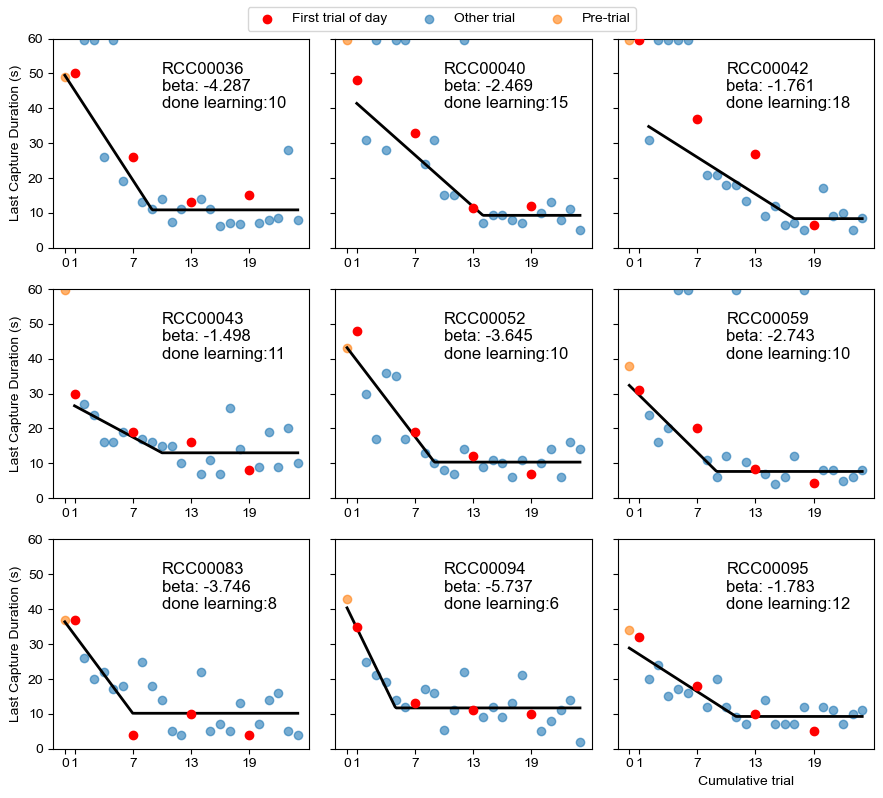

In [14]:
def flat_tail_design(x, tau):
    return np.column_stack([
        np.ones_like(x),                # intercept (plateau level)
        np.minimum(x - tau, 0)          # linear ONLY before tau
    ])

from scipy.optimize import curve_fit
def exp_decay(x, A, tau, C):
    return A * np.exp(-x / tau) + C

y_var = "last_capture_duration"; y_lab = "Last Capture Duration (s)"; tit = f"{animal} kill time last strike"; y_lim = (0,60)

fig, axes = plt.subplots(3, 3, figsize=(9, 8), sharey=True)
axes = axes.flatten()

for i, (ax, animal) in enumerate(zip(axes, animals)):

    per_trial_stats = hunt_dict[f"{animal}_PC_detail_df"]
    is_first_attempt = per_trial_stats["is_first_attempt"]

    # --- Scatter points ---
    ax.scatter(
        per_trial_stats.loc[is_first_attempt & (per_trial_stats["day"] != 0), "cumulative_trial"],
        per_trial_stats.loc[is_first_attempt & (per_trial_stats["day"] != 0), y_var],
        color="red",
        zorder=3,
        label="First trial of day"
    )

    ax.scatter(
        per_trial_stats.loc[~is_first_attempt & (per_trial_stats["day"] != 0), "cumulative_trial"],
        per_trial_stats.loc[~is_first_attempt & (per_trial_stats["day"] != 0), y_var],
        alpha=0.6,
        label="Other trial"
    )

    ax.scatter(
        per_trial_stats.loc[per_trial_stats["day"] == 0, "cumulative_trial"],
        per_trial_stats.loc[per_trial_stats["day"] == 0, y_var],
        alpha=0.6,
        label="Pre-trial"
    )

    # --- Fit flat-tail piecewise model ---
    mask = per_trial_stats["last_capture_duration"] != dummy_failed_hunt_duration
    x = per_trial_stats.loc[mask, "cumulative_trial"].values
    y = per_trial_stats.loc[mask, y_var].values

    best_tau = None
    best_rss = np.inf
    best_res = None

    taus = np.unique(x)[3:-3]

    for tau in taus:
        X = flat_tail_design(x, tau)
        res = sm.OLS(y, X).fit()
        rss = np.sum(res.resid**2)

        if rss < best_rss:
            best_rss = rss
            best_tau = tau
            best_res = res
    
    hunt_dict[f"{animal}_finish_learning_trial"] = best_tau + 1
    x_fit = np.linspace(x.min(), x.max(), 200)
    X_fit = flat_tail_design(x_fit, best_tau)
    y_fit = X_fit @ best_res.params
    alpha, beta = best_res.params

    # # Initial guesses, A: amplitude; tau: time constant, the speed of the response; C: offset / steady-state value
    # A0 = y[0] - y[-1]
    # C0 = y[-1]
    # tau0 = np.median(x)

    # popt, pcov = curve_fit(exp_decay, x, y, p0=[A0, tau0, C0],  maxfev=10000)
    # A, tau, C = popt
    # print(tau)
    
    # x_fit = np.linspace(x.min(), x.max(), 300)
    # y_fit = exp_decay(x_fit, A, tau, C)
    
    ax.plot(x_fit, y_fit,color="black", lw=2)
    ax.text(x=10, y=40, s=f"{animal}\nbeta: {beta:.3f}\ndone learning:{best_tau + 1}", size = 12)

    # --- Cosmetics ---
    ax.set_ylim(y_lim)
    ax.set_xticks([0, 1, 7, 13, 19])

    if i in [0,3,6]:
        ax.set_ylabel(y_lab)
    if i in [len(animals)-1,len(animals)-2]:
        ax.set_xlabel("Cumulative trial")

for ax in axes[len(animals):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#### ditching GLM model

Jimmy's GLM formulation (old, not used any more):
- Within-day learning: performance improves as trial increases
- Between-day forgetting: each new day has its own intercept shift
- Between-day learning: day effects accumulate positively

glm = smf.glm( formula=f"{y_var} ~ trial + C(day)", data=per_trial_stats, family=sm.families.Poisson()).fit()

#### Test whether "d2 during trial n" predicts "hunting improvement in trial n+1"

The trial improvement dataframe will have these columns:
1. Animal
2. Trial # (they are garanteed to be successful)
3. Improvement over last successful trial
4. Distance to last successful trial (if the animal hunts every roach, this will be 1; if the animal misses one roach, this will be 2; if miss 2, this will be 3, etc.)
5. normalized_improvement (Improvement over last successful trial / Distance to last successful trial) => seconds / trial
6. last successful trial hunt time (start-end tuple)
7. last successful trial rest time (start-end tuple)
8. last successful trial totoal time (start-end tuple)
9. last successful trial pre time d2
10. last successful trial eat time d2
11. last successful trial total time d2

First row with be the **second** time that the mouse successful hunted a roach.

In [8]:
y_var = "last_capture_duration"
# y_var = "capture_time_sec"
sorted_data_format = "neurons_group0.npy"

for animal in animals:
    df = hunt_dict[f"{animal}_PC_detail_df"].copy()
    df = df.iloc[0: hunt_dict[f"{animal}_finish_learning_trial"] + 1]
    success_mask = (df["last_capture_duration"] != dummy_failed_hunt_duration)
    only_success = df[success_mask]
    successful_trial_num = only_success["cumulative_trial"].values
    improvement_over_last_successful_trial, distance_to_last_successful_trial, prev_success_hunt_start, prev_success_hunt_end, trial_after_prev_start = [], [], [], [], []
    before_curr_hunt, curr_hunt_start = [], []
    for i in range(1, len(successful_trial_num)):
        # get the rows
        curr_successful_trial = df.iloc[successful_trial_num[i]]
        prev_successful_trial = df.iloc[successful_trial_num[i - 1]]
        trial_after_prev_success = df.iloc[(successful_trial_num[i-1] + 1)] # may or may not be the same as curr_successful_trial
        # comparison to last successful trial
        improvement_over_last_successful_trial.append(prev_successful_trial[y_var] - curr_successful_trial[y_var])
        distance_to_last_successful_trial.append(successful_trial_num[i] - successful_trial_num[i - 1])
        # if curr_successful_trial["is_first_attempt"]: # take 20 minutes before the start of the first attempt
        #     prev_success_hunt_start.append(curr_successful_trial["start_wall_time"] - timedelta(minutes = 20))
        #     prev_success_hunt_end.append(curr_successful_trial["start_wall_time"]- timedelta(minutes = 10))
        #     trial_after_prev_start.append(curr_successful_trial["start_wall_time"])
        # else: # compare to last trial
        prev_success_hunt_start.append(prev_successful_trial["start_wall_time"])
        prev_success_hunt_end.append(prev_successful_trial["end_wall_time"])
        trial_after_prev_start.append(min(trial_after_prev_success["start_wall_time"], # min() handles the last trial of a day
                                          prev_successful_trial["end_wall_time"] + timedelta(minutes = 10)))
        before_curr_hunt.append(curr_successful_trial["start_wall_time"]- timedelta(minutes = 10))
        curr_hunt_start.append(curr_successful_trial["start_wall_time"])
    trial_improvement_df = pd.DataFrame({
        "trial_num": successful_trial_num[1:],
        "improv_gross": improvement_over_last_successful_trial,
        "improv_dist": distance_to_last_successful_trial,
        # Jimmy will explain how to use these time points in the section that calculates d2
        "before_curr_hunt": before_curr_hunt,
        "curr_hunt_start": curr_hunt_start,
        "prev_success_hunt_start": prev_success_hunt_start,
        "prev_success_hunt_end": prev_success_hunt_end,
        "prev_success_rest_end": trial_after_prev_start,
    })

    for copy_col in ["animal", "roach_weight", "is_first_attempt", "capture_time_sec"]:
        trial_improvement_df[copy_col] = only_success[copy_col].values[1:]
    
    trial_improvement_df["improv_norm"] = trial_improvement_df["improv_gross"] / trial_improvement_df["improv_dist"]
    sorted_index_df = load_animal_neural_data_df(animal, sorting_thsd_dict, sorted_data_format)
    for time_point in ["prev_success_hunt_start", "prev_success_hunt_end", "prev_success_rest_end", "before_curr_hunt", "curr_hunt_start"]:
        trial_improvement_df[[f"{time_point}_sorted_file", f"{time_point}_info", f"{time_point}_offset_sec"]] = trial_improvement_df[time_point].apply(
            lambda t: find_matching_sorted_file(t, sorted_index_df)
        )
        trial_improvement_df = trial_improvement_df.drop(columns=[f"{time_point}_info"]) # stop dropping it during debugging
    hunt_dict[f"{animal}_improvement_df"] = trial_improvement_df

I got 58 sorted neuron objects for animal: RCC00036
I got 95 sorted neuron objects for animal: RCC00040
I got 85 sorted neuron objects for animal: RCC00042
I got 79 sorted neuron objects for animal: RCC00043
I got 95 sorted neuron objects for animal: RCC00052
I got 164 sorted neuron objects for animal: RCC00059
I got 97 sorted neuron objects for animal: RCC00083
I got 54 sorted neuron objects for animal: RCC00094


KeyError: 'RCC00095'

#### Getting spikes and calculating the d2 for each period:

**last success trial hunt phase** is from prev_success_hunt_start to prev_success_hunt_end
<br>
**last success trial rest phase** is from prev_success_hunt_end to prev_success_rest_end
<br>
**last successful trial full** is from prev_success_hunt_start to prev_success_rest_end

Jimmy's note: if the "last success trial" is followed by an unsuccessful trial, make sure that the rest phase ends at the start of the next unsuccessful trial, but not at the start of the next successful trial (which happens later)

In [ ]:
def get_binned_spikes_each_period(row, start_time_point, end_time_point, bin_size_ms = 40, minimum_d2_duration = 30):
    start_file = row[f"{start_time_point}_sorted_file"]
    end_file = row[f"{end_time_point}_sorted_file"]
    start_sec = row[f"{start_time_point}_offset_sec"]
    end_sec = row[f"{end_time_point}_offset_sec"]

    if pd.isnull(start_file) or pd.isnull(end_file):
        print(f"Jimmy didn't get both start and end file for animal: {row['animal']}, {row[start_time_point]} at row {row.name}, skipping!!!")
        return pd.Series([None, None, None])
    
    if start_file == end_file:
        if end_sec - start_sec < minimum_d2_duration:
            print(f"duration too short: {end_sec - start_sec}, not calculating d2")
            return pd.Series([None, None, None])
        total_spikes, num_neurons = get_binned_cross_spikes(start_file, start_sec, end_sec, bin_size_ms, verbose=0,
                                                            return_num_neurons = True, only_RSU=True)
    else:
        print("Handling the edge case where D2 calcualtion period spans two sorted neuron files")
        hist1, num_neurons1 = get_binned_cross_spikes(start_file, start_sec, -1, bin_size_ms, verbose=0, return_num_neurons = True, only_RSU=True)
        hist2, num_neurons2 = get_binned_cross_spikes(end_file, 0, end_sec, bin_size_ms, verbose=0, return_num_neurons = True, only_RSU=True)
        num_neurons = (num_neurons1 + num_neurons2) // 2
        mean_hist1 = np.mean(hist1)
        if mean_hist1 > 0:
            hist2_normalized = hist2 * (mean_hist1 / np.mean(hist2))
        else:
            raise ValueError("YOOOOO, hist1 is all zeros??? check it!")
        total_spikes = np.concatenate([hist1, hist2])
    num_spikes = sum(total_spikes)
    return pd.Series([total_spikes, num_neurons, num_spikes])

# LST stands for last successful trial
period_start_end_dict = {
    "LST_hunt" : ("prev_success_hunt_start", "prev_success_hunt_end"),
    "LST_rest" : ("prev_success_hunt_end", "prev_success_rest_end"),
    "LST_full" : ("prev_success_hunt_start", "prev_success_rest_end"),
    "before_trial": ("before_curr_hunt", "curr_hunt_start")
}

for animal in animals:
    trial_improvement_df = hunt_dict[f"{animal}_improvement_df"]
    for period, start_end in period_start_end_dict.items():
        trial_improvement_df[[f"{period}_binned_spikes", f"{period}_num_neurons", f"{period}_num_spikes"]] = trial_improvement_df.apply(
            lambda row: get_binned_spikes_each_period(row, start_end[0], start_end[1], bin_size_ms=15), axis=1
        )
        trial_improvement_df[f"{period}_d2_unitless"] = trial_improvement_df[f"{period}_binned_spikes"].apply(
            lambda x: safe_d2_calc(x, d2_order = 20)
        )

gc.collect() # clear out unused memory so Kiran doesn't yell at me

In [ ]:
from scipy.stats import linregress

tmp = []
for animal in animals:
    df = hunt_dict[f"{animal}_improvement_df"].copy()
    tmp.append(df[["animal", "LST_hunt_d2_unitless", "LST_rest_d2_unitless", "LST_full_d2_unitless", "before_trial_d2_unitless",
                   "improv_norm", "improv_gross", "improv_dist", "roach_weight", "is_first_attempt"]])

all_animal_improvement = pd.concat(tmp, ignore_index=True)

for data in ["improv_gross", "improv_norm"]:
    y = all_animal_improvement[data]
    all_animal_improvement[f"{data}_zero_center_log"] = np.sign(y) * np.log1p(np.abs(y))

# all_animal_improvement = all_animal_improvement[~all_animal_improvement["is_first_attempt"]]

In [ ]:
x_var = "before_trial_d2_unitless"
y_var = "improv_gross_zero_center_log"

x, y = all_animal_improvement[x_var], all_animal_improvement[y_var]
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

animal_col_val = (all_animal_improvement["animal"].values)[mask]
animal_to_color = {a: i for i, a in enumerate(animals)}
colors = np.array([animal_to_color[a] for a in animal_col_val])

# colors = (all_animal_improvement["is_first_attempt"].values)[mask]

plt.figure(figsize=(6.5, 5))

sc = plt.scatter(x, y, c=colors, cmap="tab10", alpha=0.6)

slope, intercept, r_value, p_value, stderr = linregress(x, y)
plt.text(
    0.05, 0.53,
    f"slope = {slope:.3f}\np = {p_value:.3f}\nr:={r_value:.3f}",
    transform=plt.gca().transAxes, size = 12,
    verticalalignment="top"
)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, linewidth=2)

handles = [
    plt.Line2D( [0], [0], marker='o', linestyle='',
        color=plt.cm.tab10(animal_to_color[a] / max(1, len(animals)-1)),
        label=a
    )
    for a in animals
]

plt.legend(handles=handles, title="Animal", fontsize=10)

plt.xlabel(x_var.replace("LST", "last success trial -").replace("_", " "), size = 12)
plt.ylabel("log(improvement over last trial)", size = 12)
plt.tight_layout()
plt.show()

In [ ]:
x_var = "LST_hunt_d2_unitless"
y_var = "improv_gross_zero_center_log"

x, y = all_animal_improvement[x_var], all_animal_improvement[y_var]
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

animal_col_val = (all_animal_improvement["animal"].values)[mask]
animal_to_color = {a: i for i, a in enumerate(animals)}
colors = np.array([animal_to_color[a] for a in animal_col_val])

# colors = (all_animal_improvement["is_first_attempt"].values)[mask]

plt.figure(figsize=(5, 5))

sc = plt.scatter(x, y, c=colors, cmap="tab10", alpha=0.6)

slope, intercept, r_value, p_value, stderr = linregress(x, y)
plt.text(
    0.05, 0.95,
    f"slope = {slope:.3f}\np = {p_value:.3f}\nr:={r_value:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, linewidth=2)

handles = [
    plt.Line2D( [0], [0], marker='o', linestyle='',
        color=plt.cm.tab10(animal_to_color[a] / max(1, len(animals)-1)),
        label=a
    )
    for a in animals
]
plt.legend(handles=handles, title="Animal", fontsize=8)

plt.xlabel(x_var); plt.ylabel(y_var)
plt.tight_layout()
plt.show()

#### Doing a mix effect model

In [ ]:
import statsmodels.formula.api as smf

df = all_animal_improvement[[x_var, y_var,  "is_first_attempt", "roach_weight", "animal"]].dropna()

model = smf.mixedlm(
    f"{y_var} ~ {x_var} + is_first_attempt",
    df, groups=df["animal"]
)

result = model.fit(method="lbfgs")

print(result.summary())

#### Adding d2 before each day into the equation

Copied from als_ladder/cross_analysis/criticality_baseline_files.py
<br>
The .py file should be the main copy

These represents 12 hours (3 sorting blocks) before each hunt trials.

In [ ]:
pre_first_hunt_blocks = {
    "RCC00036": {
        "RCC00036_L1_W2_2025-05-19_11-28-08_thsd_5": ["56_60", "60_64", "64_68"]
    },
    "RCC00040": {
        "RCC00040_L5_W2_2025-05-13_11-00-11_thsd_5": ["8_12", "12_16", "16_20"]
    },
    "RCC00059": {
        "RCC00059_L5_W2_2025-09-19_10-28-57_thsd_5": ["8_12", "12_16", "16_20"]
    },
    "RCC00083" : {
        "RCC00083_L5_W2_2025-11-15_17-32-17_thsd_5.5": ["0_4", "4_8", "8_12"]
    }
}

pre_second_hunt_blocks = {
    "RCC00036": {
        "RCC00036_L1_W2_2025-05-19_11-28-08_thsd_5": ["80_84", "84_88", "88_92"]
    },
    "RCC00040": {
        "RCC00040_L5_W2_2025-05-14_20-21-19_thsd_5": ["0_4", "4_8", "8_12"]
    },
    "RCC00059": {
        "RCC00059_L5_W2_2025-09-19_10-28-57_thsd_5": ["32_36", "36_40", "40_44"]
    },
    "RCC00083" : {
        "RCC00083_L5_W2_2025-11-15_17-32-17_thsd_5.5": ["24_28", "28_32", "32_36"]
    }
}

pre_third_hunt_blocks = {
    "RCC00036": {
        "RCC00036_L1_W2_2025-05-23_16-17-18_thsd_5": ["0_4"] # short, because 4_8, 8_12, 12_16 are all flatline
    },
    "RCC00040": {
        "RCC00040_L5_W2_2025-05-14_20-21-19_thsd_5": ["28_32", "32_36", "36_40"]
    },
    "RCC00059": {
        "RCC00059_L5_W2_2025-09-19_10-28-57_thsd_5": ["60_64", "64_68", "68_72"]
    },
    "RCC00083" : {
        "RCC00083_L5_W2_2025-11-17_14-51-46_thsd_5.5": ["4_8", "8_12", "12_16"]
    }
}

pre_fourth_hunt_blocks = {
    "RCC00036": {
        "RCC00036_L1_W2_2025-05-23_16-17-18_thsd_5": ["28_32", "32_36", "36_40"]
    },
    "RCC00040": {
        "RCC00040_L5_W2_2025-05-16_14-48-58_thsd_5": ["4_8", "8_12", "12_16"]
    },
    "RCC00059": {
        "RCC00059_L5_W2_2025-09-22_08-54-35_thsd_5": ["12_16", "16_20", "20_24"]
    },
    "RCC00083" : {
        "RCC00083_L5_W2_2025-11-17_14-51-46_thsd_5.5": ["28_32", "32_36", "36_40"]
    }
}

def get_d2_all_baseline(animal, block_dict, d2_bin_size_ms = 15, d2_order = 20,
                        d2_calculate_duration = 1200):
    num_bin_per_d2 = int(d2_calculate_duration / (d2_bin_size_ms / 1000))
    d2_list = []
    restart_blockhours_dict = block_dict[animal]
    for restart, hour_blocks in restart_blockhours_dict.items():
        for hour_block in hour_blocks:
            base_str = f"/media/HlabShare/Clustering_Data/{animal}/block_4hr/{restart}*/{hour_block}/probe1/co"
            clean_obj = glob.glob(f"{base_str}/*_neurons_group0_clean.npy")
            norm_obj = glob.glob(f"{base_str}/*_neurons_group0.npy")
            filename = None
            if clean_obj and "RCC00083" not in animal:
                filename = clean_obj[0]
            elif norm_obj:
                filename = norm_obj[0]
                print(f"WARNING: using un-inspected file: {filename}")
            else:
                print(f"didn't find any: {base_str}/*_neurons_group0.npy")
            neurons = np.load(filename, allow_pickle = True)
            neurons_filt = [neuron for neuron in neurons if (neuron.quality <= 2) and neuron.cell_type == 'RSU']
            neuron = neurons_filt[0]
            rec_ends = neuron.off_times[-1] if neuron.off_times else neuron.end_time
            rec_starts = neuron.on_times[0] if neuron.on_times else neuron.start_time
            print(f"Current RSU count for hour {hour_block}, {animal} = {len(neurons_filt)}, start: {rec_starts}, end: {rec_ends}")
            cur_start = rec_starts
            # calcualting d2 in 1 neuron objects
            while cur_start + d2_calculate_duration -1 < rec_ends:
                cur_end = cur_start + d2_calculate_duration
                total_hist = np.zeros(num_bin_per_d2)
                for i, n in enumerate(neurons_filt):
                    spike_times = np.asarray(n.spike_time_sec_onoff)
                    spike_times = spike_times[(spike_times >= cur_start) & (spike_times < cur_end)]
                    if spike_times.size == 0:
                        continue  # skip empty neurons
                    hist, _ = np.histogram(spike_times, bins=num_bin_per_d2, range=(cur_start, cur_end))
                    total_hist += hist
                cur_start += d2_calculate_duration
                prop_zeros = round(sum(total_hist == 0) / num_bin_per_d2, 3)
                if (sum(total_hist[:10] ==0) == 10) or (sum(total_hist[-10:] ==0) == 10):
                    print("start or end empty, skip (likely due to on-off time)")
                    continue
                z = zscore(total_hist)
                d2 = sm_d2(z, d2_order)
                d2_list.append(round(d2, 5))
    return d2_list

recording_blocks = [pre_first_hunt_blocks, pre_second_hunt_blocks, pre_third_hunt_blocks, pre_fourth_hunt_blocks]
hunt_dict = {}
for animal in animals:
    for i, pre_hunt_blocks in enumerate(recording_blocks):
        d2_list = get_d2_all_baseline(animal, pre_hunt_blocks)
        d2_mean = round(np.mean(d2_list),5)
        d2_std = np.std(d2_list)
        hunt_dict[f"{animal}_day{i + 1}"] = {
            f"d2_list": d2_list,
            f"d2_mean": d2_mean,
            f"d2_std": d2_std,
            f"d2_sem": d2_std / np.sqrt(len(d2_list))
        }

In [ ]:
# change this
y_var = "num_of_attempts"; y_lab = "Number of attempts"; tit = f"{animal} hunting performance overtime"; y_lim = (0,11)
# y_var = "total_contact_duration"; y_lab = "total contact duration (s)"; tit = f"{animal} hunting duration (last attempt is recorded as 0 second)"; y_lim = (-1,45)
# y_var = "avg_contact_duration"; y_lab = "average contact duration (s)"; tit = f"{animal} average contact duration"; y_lim = (-1,10)
# y_var = "contact_density"; y_lab = "contact density (seconds / per strike)"; tit = f"{animal} strike / contact density"; y_lim = (0, 500)

num_row, num_col = 2, 2
fig, axes = plt.subplots(num_row, num_col, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, (ax, animal) in enumerate(zip(axes, animals)):
    per_trial_stats = hunt_dict[f"{animal}_PC_detail_df"]    
    # -------------------------
    # Scatter plot (left axis)
    # -------------------------
    ax.scatter(
        x=per_trial_stats.loc[is_first_attempt, "cumulative_trial"],
        y=per_trial_stats.loc[is_first_attempt, y_var],
        color="red",
        zorder=3,
        label="First trial of day"
    )
    
    ax.scatter(
        x=per_trial_stats.loc[~is_first_attempt, "cumulative_trial"],
        y=per_trial_stats.loc[~is_first_attempt, y_var],
        alpha=0.6,
        label="Other trials"
    )
    
    ax.set_xlabel("Cumulative trial", size=14)
    if i % num_col == 0:
        ax.set_ylabel(y_lab, size=14)
    ax.set_ylim(y_lim)
    ax.set_title(animal)
    ax.set_xticks(range(0, 25, 6))
    
    # -------------------------
    # Boxplot axis (right axis)
    # -------------------------
    ax2 = ax.twinx()
    
    # Collect d2 lists
    d2_data = [
        hunt_dict[f"{animal}_day{d}"]["d2_list"]
        for d in [1, 2, 3, 4]
    ]
    
    # Choose x-positions for each day
    # Example: center boxes roughly within each day's trials
    day_centers = [
        per_trial_stats.loc[per_trial_stats["day"] == d, "cumulative_trial"].mean()
        for d in days
    ]
    
    bp = ax2.boxplot(
        d2_data,
        positions=day_centers,
        widths=1.5,
        patch_artist=True,
        showfliers=False,
        zorder=2
    )
    
    # Style boxplots
    for box in bp["boxes"]:
        box.set(facecolor="orange", alpha=0.25, edgecolor="orange")
    
    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set(color="black")
    
    ax2.set_ylim(0, 0.25)
    if i % num_col == num_col - 1:
        ax2.set_ylabel("d2", size=14, color = "orange")
    ax2.tick_params(
        axis="y",
        colors="orange",      # sets BOTH ticks and labels
        labelsize=12
    )
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    # frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# change this
y_var = "num_of_attempts"; y_lab = "Number of attempts"; tit = f"{animal} hunting performance overtime"; y_lim = (0,11)
# y_var = "total_contact_duration"; y_lab = "total contact duration (s)"; tit = f"{animal} hunting duration (last attempt is recorded as 0 second)"; y_lim = (-1,45)
# y_var = "avg_contact_duration"; y_lab = "average contact duration (s)"; tit = f"{animal} average contact duration"; y_lim = (-1,10)
# y_var = "contact_density"; y_lab = "contact density (seconds / per strike)"; tit = f"{animal} strike / contact density"; y_lim = (0, 500)

plt.figure(figsize=(6, 4))
plt.scatter(
    x=per_trial_stats.loc[is_first_attempt, "cumulative_trial"],
    y=per_trial_stats.loc[is_first_attempt, y_var],
    color="red",
    zorder=3,
    label="First trial of day"
)

plt.scatter(
    x=per_trial_stats.loc[~is_first_attempt, "cumulative_trial"],
    y=per_trial_stats.loc[~is_first_attempt, y_var],
    alpha=0.6,
    label="other trial"
)

plt.xticks(range(0, 25, 6))
plt.xlabel("Cumulative trial", size = 14)
plt.ylabel(y_lab, size = 14)
plt.ylim(y_lim)
plt.title(tit)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for day in range(1,5):
for animal in animals:
    short_animal = animal.replace("Ladder", "")
    d2_list = get_d2_all_baseline(short_animal, baseline_blocks)
    d2_mean = round(np.mean(d2_list),5)
    d2_std = np.std(d2_list)
    # print(d2_list)
    hunt_dict[short_animal] = {
        "d2_list": d2_list,
        "d2_mean": d2_mean,
        "d2_std": d2_std,
        "d2_sem": d2_std / np.sqrt(len(d2_list))
    }

#### Juntian's Plot on Dec 12th 2025

In [ ]:
counts = per_trial_stats['num_of_attempts'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=counts.index, y=counts.values, color='steelblue', edgecolor='black')

# set labels
plt.xlabel('Number of Attempts till Success')  # X
plt.ylabel('Count of Trials')                  # Y
plt.title('Distribution of Attempts per Trial')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.show()